✅ Загружено 400 записей
✅ После очистки: 400 записей

🚀 ЗАПУСК АВТОМАТИЗИРОВАННОЙ СИСТЕМЫ АНАЛИЗА

📊 РАСЧЕТ ПОКАЗАТЕЛЕЙ ВЫПОЛНЕН
   Общая выручка: 49,918,197
   Общая прибыль: 16,220,799
   Рентабельность: 32.5%
   Прибыльных дней: 307 (76.8%)

📈 АНАЛИЗ ТРЕНДОВ ВЫПОЛНЕН
   revenue: снижение на -0.01% в день
   expenses: рост на 0.01% в день
   profit: снижение на -0.07% в день
   customers: рост на 0.01% в день
   orders: снижение на -0.02% в день

🔗 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ВЫПОЛНЕН
   revenue ↔ profit: 0.75 (положительная)
   expenses ↔ profit: -0.61 (отрицательная)

⚠️ ОБНАРУЖЕНЫ АНОМАЛИИ
   profit: 12 аномалий (3.0%)


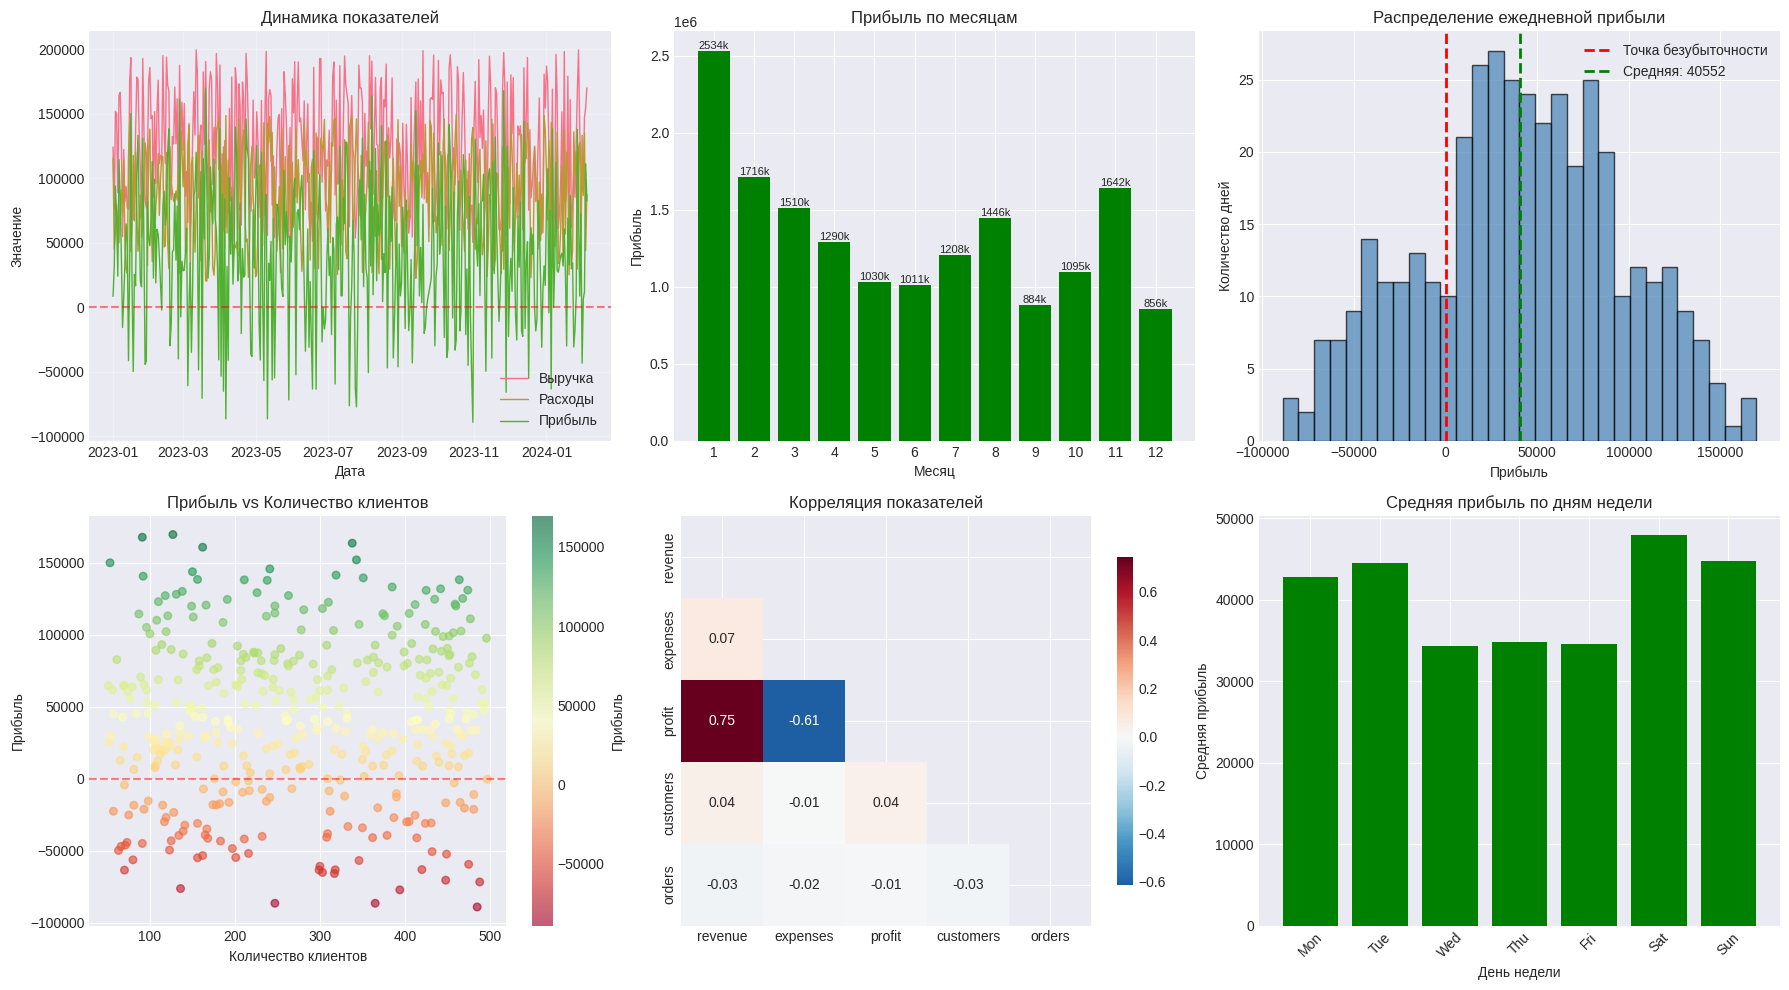


📊 ПОСТРОЕНО 6 ГРАФИКОВ (сохранено как 'full_analysis_report.png')

                         АНАЛИТИЧЕСКИЙ ОТЧЕТ

📋 1. ОБЩАЯ ИНФОРМАЦИЯ
------------------------------------------------------------
   Период анализа: 01.01.2023 - 04.02.2024
   Количество дней: 400

💰 2. КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ
------------------------------------------------------------
   Общая выручка:       49,918,197
   Общие расходы:       33,697,398
   Общая прибыль:       16,220,799
   Рентабельность:           32.5%
   Средняя прибыль/день:    40,552

📊 3. СТАТИСТИКА ПРИБЫЛЬНОСТИ
------------------------------------------------------------
   Прибыльных дней:   307 (76.8%)
   Убыточных дней:    93 (23.2%)
   Макс. прибыль:          169,601 (20.03.2023)
   Макс. убыток:           -89,039 (31.10.2023)

📈 4. ТРЕНДЫ
------------------------------------------------------------
   revenue    ▼ снижение на  -0.01% в день
   expenses   ▲ рост   на   0.01% в день
   profit     ▼ снижение на  -0.07% в день
   customers  ▲ рос

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class DataAnalysisSystem:
    """
    Автоматизированная система анализа показателей деятельности организации
    """

    def __init__(self, data_source):
        self.raw_data = None
        self.data = None
        self.results = {}  # Здесь будем хранить все результаты
        self.load_data(data_source)

    # ==================== 1. ПОДГОТОВКА ДАННЫХ ====================

    def load_data(self, source):
        """Загрузка данных"""
        if isinstance(source, pd.DataFrame):
            self.raw_data = source.copy()
        elif isinstance(source, str):
            if source.endswith('.csv'):
                self.raw_data = pd.read_csv(source)
            elif source.endswith(('.xls', '.xlsx')):
                self.raw_data = pd.read_excel(source)
        else:
            raise ValueError("Неподдерживаемый источник")

        print(f"✅ Загружено {len(self.raw_data)} записей")
        self.clean_data()

    def clean_data(self):
        """Очистка данных"""
        self.data = self.raw_data.copy()

        # Конвертация даты
        if 'date' in self.data.columns:
            self.data['date'] = pd.to_datetime(self.data['date'])
            self.data['year'] = self.data['date'].dt.year
            self.data['month'] = self.data['date'].dt.month
            self.data['day_of_week'] = self.data['date'].dt.dayofweek
            self.data['day_name'] = self.data['date'].dt.day_name()

        # Проверка на пропуски
        if self.data.isnull().sum().sum() > 0:
            print(f"⚠️ Обнаружены пропуски: {self.data.isnull().sum().sum()}")
            self.data = self.data.dropna()

        print(f"✅ После очистки: {len(self.data)} записей")

        # Сохраняем описание данных
        self.results['description'] = {
            'start_date': self.data['date'].min(),
            'end_date': self.data['date'].max(),
            'days': len(self.data),
            'columns': list(self.data.columns)
        }

    # ==================== 2. РАСЧЕТ ПОКАЗАТЕЛЕЙ ====================

    def calculate_metrics(self):
        """Расчет всех показателей"""

        # 1. Суммарные показатели
        self.results['sums'] = {
            'total_revenue': self.data['revenue'].sum(),
            'total_expenses': self.data['expenses'].sum(),
            'total_profit': self.data['profit'].sum(),
            'total_customers': self.data['customers'].sum(),
            'total_orders': self.data['orders'].sum()
        }

        # 2. Средние значения
        self.results['averages'] = {
            'avg_revenue': self.data['revenue'].mean(),
            'avg_expenses': self.data['expenses'].mean(),
            'avg_profit': self.data['profit'].mean(),
            'avg_customers': self.data['customers'].mean(),
            'avg_orders': self.data['orders'].mean()
        }

        # 3. Медианы
        self.results['medians'] = {
            'median_revenue': self.data['revenue'].median(),
            'median_expenses': self.data['expenses'].median(),
            'median_profit': self.data['profit'].median(),
            'median_customers': self.data['customers'].median(),
            'median_orders': self.data['orders'].median()
        }

        # 4. Долевые показатели
        self.results['ratios'] = {
            'expense_to_revenue_ratio': (self.data['expenses'].sum() / self.data['revenue'].sum()) * 100,
            'profit_margin': (self.data['profit'].sum() / self.data['revenue'].sum()) * 100,
            'avg_profit_per_customer': (self.data['profit'].sum() / self.data['customers'].sum()),
            'avg_revenue_per_order': (self.data['revenue'].sum() / self.data['orders'].sum()),
            'avg_orders_per_customer': (self.data['orders'].sum() / self.data['customers'].sum())
        }

        # 5. Статистика прибыли
        profit_positive = (self.data['profit'] > 0).sum()
        self.results['profit_stats'] = {
            'profitable_days': profit_positive,
            'unprofitable_days': len(self.data) - profit_positive,
            'profitable_days_pct': (profit_positive / len(self.data)) * 100,
            'max_profit': self.data['profit'].max(),
            'max_loss': self.data['profit'].min(),
            'max_profit_date': self.data.loc[self.data['profit'].idxmax(), 'date'],
            'max_loss_date': self.data.loc[self.data['profit'].idxmin(), 'date'],
            'profit_std': self.data['profit'].std()
        }

        # 6. Динамика (сравнение с предыдущим днем)
        self.data['revenue_change'] = self.data['revenue'].pct_change() * 100
        self.data['profit_change'] = self.data['profit'].pct_change() * 100

        self.results['dynamics'] = {
            'avg_daily_revenue_change': self.data['revenue_change'].mean(),
            'avg_daily_profit_change': self.data['profit_change'].mean(),
            'max_daily_revenue_growth': self.data['revenue_change'].max(),
            'max_daily_revenue_decline': self.data['revenue_change'].min()
        }

        # 7. Помесячные показатели
        monthly = self.data.groupby('month').agg({
            'revenue': 'sum',
            'expenses': 'sum',
            'profit': 'sum',
            'customers': 'sum',
            'orders': 'sum'
        }).round(0)

        self.results['monthly'] = monthly
        self.results['best_month'] = monthly['profit'].idxmax()
        self.results['worst_month'] = monthly['profit'].idxmin()

        print("\n📊 РАСЧЕТ ПОКАЗАТЕЛЕЙ ВЫПОЛНЕН")
        print(f"   Общая выручка: {self.results['sums']['total_revenue']:,.0f}")
        print(f"   Общая прибыль: {self.results['sums']['total_profit']:,.0f}")
        print(f"   Рентабельность: {self.results['ratios']['profit_margin']:.1f}%")
        print(f"   Прибыльных дней: {self.results['profit_stats']['profitable_days']} ({self.results['profit_stats']['profitable_days_pct']:.1f}%)")

        return self.results

    # ==================== 3. АНАЛИЗ ТРЕНДОВ ====================

    def analyze_trends(self):
        """Выявление трендов"""

        trends = {}

        # Линейная регрессия для каждого показателя
        X = np.arange(len(self.data)).reshape(-1, 1)

        for metric in ['revenue', 'expenses', 'profit', 'customers', 'orders']:
            y = self.data[metric].values
            model = LinearRegression()
            model.fit(X, y)

            slope = model.coef_[0]
            slope_pct = (slope / self.data[metric].mean()) * 100

            trends[metric] = {
                'direction': 'рост' if slope > 0 else 'снижение',
                'daily_change': slope,
                'daily_change_pct': slope_pct,
                'trend_strength': abs(slope_pct),
                'r2': model.score(X, y)
            }

        self.results['trends'] = trends

        # Тренд по дням недели
        weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        weekday_profit = self.data.groupby('day_name')['profit'].mean().reindex(weekday_order)
        self.results['weekday_profit'] = weekday_profit
        self.results['best_weekday'] = weekday_profit.idxmax()
        self.results['worst_weekday'] = weekday_profit.idxmin()

        print("\n📈 АНАЛИЗ ТРЕНДОВ ВЫПОЛНЕН")
        for metric, trend in trends.items():
            print(f"   {metric}: {trend['direction']} на {trend['daily_change_pct']:.2f}% в день")

        return trends

    # ==================== 4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ====================

    def analyze_correlations(self):
        """Поиск зависимостей"""

        # Корреляционная матрица
        corr_matrix = self.data[['revenue', 'expenses', 'profit', 'customers', 'orders']].corr()
        self.results['correlations'] = corr_matrix

        # Сильные корреляции
        strong_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.5:
                    strong_corr.append({
                        'pair': f"{corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}",
                        'value': corr_val,
                        'type': 'положительная' if corr_val > 0 else 'отрицательная'
                    })

        self.results['strong_correlations'] = strong_corr

        # Факторы, влияющие на прибыль
        profit_factors = corr_matrix['profit'].drop('profit').sort_values(ascending=False)
        self.results['profit_factors'] = profit_factors

        print("\n🔗 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ВЫПОЛНЕН")
        for corr in strong_corr[:3]:
            print(f"   {corr['pair']}: {corr['value']:.2f} ({corr['type']})")

        return strong_corr

    # ==================== 5. АНОМАЛИИ ====================

    def detect_anomalies(self):
        """Обнаружение аномалий"""

        anomalies = {}

        for metric in ['revenue', 'expenses', 'profit']:
            mean = self.data[metric].mean()
            std = self.data[metric].std()

            # Аномалии: значения дальше 2 стандартных отклонений
            anomaly_mask = abs(self.data[metric] - mean) > 2 * std
            anomaly_count = anomaly_mask.sum()

            if anomaly_count > 0:
                anomalies[metric] = {
                    'count': int(anomaly_count),
                    'percentage': (anomaly_count / len(self.data)) * 100,
                    'dates': self.data[anomaly_mask]['date'].dt.strftime('%Y-%m-%d').tolist()[:5]
                }

        self.results['anomalies'] = anomalies

        if anomalies:
            print("\n⚠️ ОБНАРУЖЕНЫ АНОМАЛИИ")
            for metric, info in anomalies.items():
                print(f"   {metric}: {info['count']} аномалий ({info['percentage']:.1f}%)")

        return anomalies

    # ==================== 6. ВИЗУАЛИЗАЦИЯ ====================

    def create_visualizations(self):
        """Построение всех графиков"""

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        # График 1: Динамика выручки, расходов, прибыли
        ax1 = axes[0, 0]
        ax1.plot(self.data['date'], self.data['revenue'], label='Выручка', linewidth=1)
        ax1.plot(self.data['date'], self.data['expenses'], label='Расходы', linewidth=1)
        ax1.plot(self.data['date'], self.data['profit'], label='Прибыль', linewidth=1)
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax1.set_title('Динамика показателей')
        ax1.set_xlabel('Дата')
        ax1.set_ylabel('Значение')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # График 2: Прибыль по месяцам (столбчатая)
        ax2 = axes[0, 1]
        monthly_profit = self.results['monthly']['profit']
        colors = ['red' if x < 0 else 'green' for x in monthly_profit.values]
        bars = ax2.bar(range(len(monthly_profit)), monthly_profit.values, color=colors)
        ax2.set_xticks(range(len(monthly_profit)))
        ax2.set_xticklabels(monthly_profit.index)
        ax2.set_title('Прибыль по месяцам')
        ax2.set_xlabel('Месяц')
        ax2.set_ylabel('Прибыль')
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

        # Добавляем значения на столбцы
        for bar, val in zip(bars, monthly_profit.values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val/1000:.0f}k', ha='center', va='bottom' if val > 0 else 'top', fontsize=8)

        # График 3: Распределение прибыли
        ax3 = axes[0, 2]
        ax3.hist(self.data['profit'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Точка безубыточности')
        ax3.axvline(x=self.results['averages']['avg_profit'], color='green', linestyle='--', linewidth=2,
                   label=f"Средняя: {self.results['averages']['avg_profit']:.0f}")
        ax3.set_title('Распределение ежедневной прибыли')
        ax3.set_xlabel('Прибыль')
        ax3.set_ylabel('Количество дней')
        ax3.legend()

        # График 4: Зависимость прибыли от клиентов
        ax4 = axes[1, 0]
        scatter = ax4.scatter(self.data['customers'], self.data['profit'],
                             c=self.data['profit'], cmap='RdYlGn', alpha=0.6, s=30)
        ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax4.set_title('Прибыль vs Количество клиентов')
        ax4.set_xlabel('Количество клиентов')
        ax4.set_ylabel('Прибыль')
        plt.colorbar(scatter, ax=ax4, label='Прибыль')

        # График 5: Тепловая карта корреляций
        ax5 = axes[1, 1]
        corr = self.results['correlations']
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                   center=0, square=True, ax=ax5, cbar_kws={'shrink': 0.8})
        ax5.set_title('Корреляция показателей')

        # График 6: Прибыль по дням недели
        ax6 = axes[1, 2]
        weekday_data = self.results['weekday_profit']
        colors_wd = ['red' if x < 0 else 'green' for x in weekday_data.values]
        bars_wd = ax6.bar(range(len(weekday_data)), weekday_data.values, color=colors_wd)
        ax6.set_xticks(range(len(weekday_data)))
        ax6.set_xticklabels([d[:3] for d in weekday_data.index], rotation=45)
        ax6.set_title('Средняя прибыль по дням недели')
        ax6.set_xlabel('День недели')
        ax6.set_ylabel('Средняя прибыль')
        ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

        plt.tight_layout()
        plt.savefig('full_analysis_report.png', dpi=150, bbox_inches='tight')
        plt.show()

        print("\n📊 ПОСТРОЕНО 6 ГРАФИКОВ (сохранено как 'full_analysis_report.png')")

    # ==================== 7. ГЕНЕРАЦИЯ ОТЧЕТА ====================

    def generate_recommendations(self):
        """Генерация рекомендаций на основе данных"""

        recommendations = []

        # Рекомендации на основе рентабельности
        margin = self.results['ratios']['profit_margin']
        if margin < 10:
            recommendations.append("КРИТИЧЕСКАЯ: Рентабельность ниже 10% - срочно оптимизируйте расходы!")
        elif margin < 20:
            recommendations.append("ВАЖНАЯ: Рентабельность ниже среднего (20%) - ищите точки роста")
        else:
            recommendations.append("ПОЗИТИВ: Хорошая рентабельность - продолжайте в том же духе")

        # На основе убыточных дней
        unprofit_pct = 100 - self.results['profit_stats']['profitable_days_pct']
        if unprofit_pct > 30:
            recommendations.append(f"КРИТИЧЕСКАЯ: {unprofit_pct:.0f}% дней убыточны - требуется анализ причин")
        elif unprofit_pct > 20:
            recommendations.append(f"ВАЖНАЯ: {unprofit_pct:.0f}% дней убыточны - оптимизируйте управление")

        # На основе тренда прибыли
        profit_trend = self.results['trends']['profit']
        if profit_trend['direction'] == 'снижение':
            recommendations.append(f"ТРЕВОГА: Прибыль снижается на {abs(profit_trend['daily_change_pct']):.2f}% в день!")

        # На основе корреляций
        if 'expenses' in self.results['profit_factors'].index:
            exp_corr = self.results['profit_factors']['expenses']
            if exp_corr < -0.5:
                recommendations.append("Расходы сильно снижают прибыль - внедрите систему контроля расходов")

        # На основе сезонности
        best_m = self.results['best_month']
        worst_m = self.results['worst_month']
        recommendations.append(f"ПЛАНИРОВАНИЕ: Лучший месяц - {best_m}, худший - {worst_m}. Планируйте запасы и маркетинг с учетом сезонности")

        # На основе дней недели
        if self.results['best_weekday'] and self.results['worst_weekday']:
            recommendations.append(f"ОПЕРАЦИОННО: Лучший день - {self.results['best_weekday']}, худший - {self.results['worst_weekday']}. Рассмотрите акции в слабые дни")

        self.results['recommendations'] = recommendations
        return recommendations

    def print_full_report(self):
        """Печать полного отчета"""

        print("\n" + "="*80)
        print(" " * 25 + "АНАЛИТИЧЕСКИЙ ОТЧЕТ")
        print("="*80)

        # 1. Общая информация
        print("\n📋 1. ОБЩАЯ ИНФОРМАЦИЯ")
        print("-" * 60)
        print(f"   Период анализа: {self.results['description']['start_date'].strftime('%d.%m.%Y')} - {self.results['description']['end_date'].strftime('%d.%m.%Y')}")
        print(f"   Количество дней: {self.results['description']['days']}")

        # 2. Ключевые показатели
        print("\n💰 2. КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ")
        print("-" * 60)
        print(f"   Общая выручка:     {self.results['sums']['total_revenue']:>12,.0f}")
        print(f"   Общие расходы:     {self.results['sums']['total_expenses']:>12,.0f}")
        print(f"   Общая прибыль:     {self.results['sums']['total_profit']:>12,.0f}")
        print(f"   Рентабельность:    {self.results['ratios']['profit_margin']:>11.1f}%")
        print(f"   Средняя прибыль/день: {self.results['averages']['avg_profit']:>9,.0f}")

        # 3. Статистика прибыльности
        print("\n📊 3. СТАТИСТИКА ПРИБЫЛЬНОСТИ")
        print("-" * 60)
        print(f"   Прибыльных дней:   {self.results['profit_stats']['profitable_days']} ({self.results['profit_stats']['profitable_days_pct']:.1f}%)")
        print(f"   Убыточных дней:    {self.results['profit_stats']['unprofitable_days']} ({100-self.results['profit_stats']['profitable_days_pct']:.1f}%)")
        print(f"   Макс. прибыль:     {self.results['profit_stats']['max_profit']:>12,.0f} ({self.results['profit_stats']['max_profit_date'].strftime('%d.%m.%Y')})")
        print(f"   Макс. убыток:      {self.results['profit_stats']['max_loss']:>12,.0f} ({self.results['profit_stats']['max_loss_date'].strftime('%d.%m.%Y')})")

        # 4. Тренды
        print("\n📈 4. ТРЕНДЫ")
        print("-" * 60)
        for metric, trend in self.results['trends'].items():
            arrow = "▲" if trend['direction'] == 'рост' else "▼"
            print(f"   {metric:10} {arrow} {trend['direction']:6} на {trend['daily_change_pct']:6.2f}% в день")

        # 5. Корреляции
        print("\n🔗 5. ЗАВИСИМОСТИ (сильные корреляции)")
        print("-" * 60)
        for corr in self.results.get('strong_correlations', []):
            print(f"   {corr['pair']:25} {corr['value']:6.2f} ({corr['type']})")

        # 6. Сезонность
        print("\n📅 6. СЕЗОННОСТЬ")
        print("-" * 60)
        print(f"   Лучший месяц по прибыли:   {self.results['best_month']}")
        print(f"   Худший месяц по прибыли:   {self.results['worst_month']}")
        print(f"   Лучший день недели:        {self.results['best_weekday']}")
        print(f"   Худший день недели:        {self.results['worst_weekday']}")

        # 7. Аномалии
        if self.results.get('anomalies'):
            print("\n⚠️ 7. ОБНАРУЖЕННЫЕ АНОМАЛИИ")
            print("-" * 60)
            for metric, info in self.results['anomalies'].items():
                print(f"   {metric}: {info['count']} аномальных дней ({info['percentage']:.1f}%)")
                if info['dates']:
                    print(f"      Даты: {', '.join(info['dates'][:3])}")

        # 8. Рекомендации
        print("\n💡 8. РЕКОМЕНДАЦИИ")
        print("-" * 60)
        for i, rec in enumerate(self.results['recommendations'], 1):
            print(f"   {i}. {rec}")

        print("\n" + "="*80)
        print(" " * 30 + "КОНЕЦ ОТЧЕТА")
        print("="*80)

    # ==================== 8. ЗАПУСК ВСЕГО АНАЛИЗА ====================

    def run_full_analysis(self):
        """Запуск полного анализа"""

        print("\n🚀 ЗАПУСК АВТОМАТИЗИРОВАННОЙ СИСТЕМЫ АНАЛИЗА")
        print("="*60)

        self.calculate_metrics()
        self.analyze_trends()
        self.analyze_correlations()
        self.detect_anomalies()
        self.generate_recommendations()
        self.create_visualizations()
        self.print_full_report()

        print("\n✅ АНАЛИЗ ПОЛНОСТЬЮ ЗАВЕРШЕН!")

        return self.results


# ==================== ЗАПУСК ====================

# Загружаем ваши данные
df = pd.read_csv('data1.csv')  # или укажите путь к вашему файлу

# Создаем систему
analyzer = DataAnalysisSystem(df)

# Запускаем полный анализ
results = analyzer.run_full_analysis()